In [1]:
import pdblp

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt



from xbbg import blp
from datetime import datetime, timedelta


from datetime import datetime, timedelta


from scipy.signal import savgol_filter

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf

In [2]:
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=365)).strftime("%Y-%m-%d")

ccy = 'EURUSD'

ticker_IV = f"{ccy} BGN Curncy"
data_spot = blp.bdh(
    tickers=ticker_IV,
    flds="PX_LAST",
    start_date=start_date,
    end_date=end_date
)
data_spot.columns = [ccy]

# data_spot['moving_Smooth_'] = data_spot['EURUSD'].ewm(span=10, adjust=False).mean()

data_spot['moving_Smooth'] = savgol_filter(data_spot['EURUSD'], window_length=21, polyorder=2)

data_spot.index = pd.to_datetime(data_spot.index)

data_spot['spot-moving_Smooth'] = data_spot['moving_Smooth'] - data_spot['EURUSD']

one_STD = data_spot['spot-moving_Smooth'].std()


data_spot['Above_Below_STD'] = (
    (data_spot['spot-moving_Smooth'] > one_STD) | 
    (data_spot['spot-moving_Smooth'] < -one_STD)
)



return_times = []

# Loop through rows where `Above_Below_STD` is True
for index, row in data_spot[data_spot['Above_Below_STD']].iterrows():
    # Find the subsequent rows
    subsequent_data = data_spot.loc[index:]
    
    # Check when EURUSD returns to moving_Smooth
    return_event = subsequent_data[subsequent_data['EURUSD'] <= subsequent_data['moving_Smooth']].head(1)
    
    # If a return event is found, calculate the time difference
    if not return_event.empty:
        return_time = (return_event.index[0] - index).days
        return_times.append(return_time)

# Calculate the average return time
if return_times:
    average_return_time = sum(return_times) / len(return_times)
    print(f"Average time to return to moving_Smooth: {average_return_time:.2f} days")
else:
    print("No return events found.")



Average time to return to moving_Smooth: 1.71 days


KeyError: '5D_EMA'

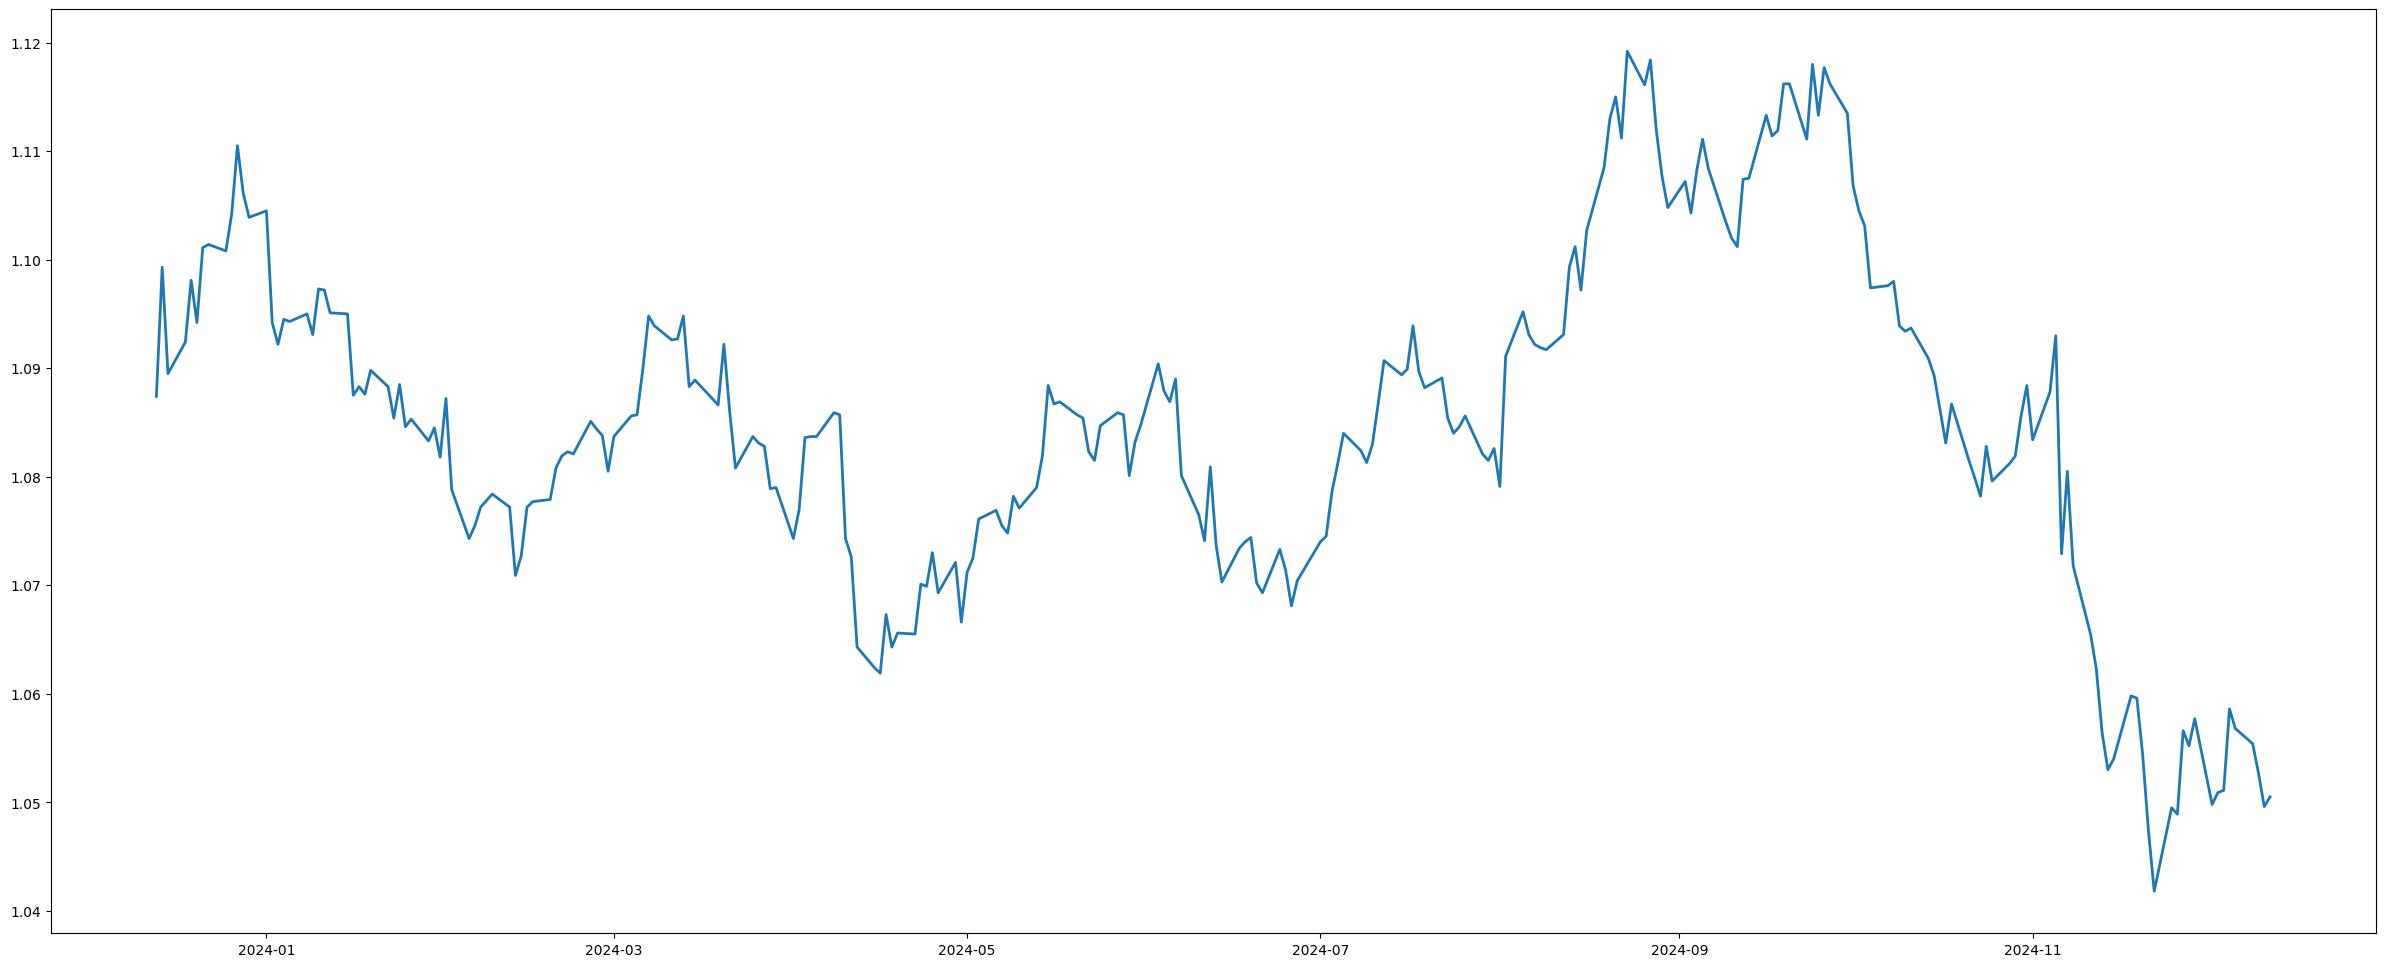

In [3]:
plt.figure(figsize=(30, 12))
plt.plot(data_spot.index, data_spot["EURUSD"], label="EURUSD", linewidth=2)
plt.plot(data_spot.index, data_spot['5D_EMA'], label="5-Day EMA")
# plt.plot(data_spot.index, data_spot['moving_Smooth'], label="Smoothed Path")
plt.title("EURUSD Implied Volatility over Last Year")
plt.xlabel("Date")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
# Define currency pairs




def getMeanRevertion(currency_pairs):

    average_return_times = []

    # Connect to Bloomberg
    con = pdblp.BCon(debug=False, port=8194, timeout=5000)
    con.start()

    # Loop through each currency pair
    for ccy in currency_pairs:
        
        start_date = (datetime.now() - timedelta(days=365)).strftime("%Y-%m-%d")
        end_date = datetime.now().strftime("%Y-%m-%d")
        
        ticker_IV = f"{ccy} BGN Curncy"
        data_spot = blp.bdh(
            tickers=ticker_IV,
            flds="PX_LAST",
            start_date=start_date,
            end_date=end_date
        )
        data_spot.columns = [ccy]
        
        # Calculate 5D EMA
        data_spot['5D_EMA'] = data_spot[ccy].ewm(span=5, adjust=False).mean()
        
        # Calculate spot-5D_EMA
        data_spot['spot-5D_EMA'] = data_spot['5D_EMA'] - data_spot[ccy]
        
        # Calculate 1 standard deviation
        one_STD = data_spot['spot-5D_EMA'].std()
        
        # Identify above/below STD
        data_spot['Above_Below_STD'] = (
            (data_spot['spot-5D_EMA'] > one_STD) |
            (data_spot['spot-5D_EMA'] < -one_STD)
        )
        
        # Calculate return times
        return_times = []
        for index, row in data_spot[data_spot['Above_Below_STD']].iterrows():
            # Find subsequent rows
            subsequent_data = data_spot.loc[index:]
            
            # Check when ccy returns to 5D_EMA
            return_event = subsequent_data[subsequent_data[ccy] <= subsequent_data['5D_EMA']].head(1)
            
            # If a return event is found, calculate the time difference
            if not return_event.empty:
                return_time = (return_event.index[0] - index).days
                return_times.append(return_time)
        
        # Calculate the average return time for the current currency pair
        if return_times:
            average_return_time = sum(return_times) / len(return_times)
        else:
            average_return_time = None  # Handle cases with no return events
        
        # Fetch 1-year historical volatility
        HV_data = con.ref(f"{ccy}V1W Curncy", ["PX_LAST"])  
        hist_1YVol = HV_data['value'].iloc[0]
        
        # Store the result including hist_1YVol
        average_return_times.append({
            'Currency Pair': ccy,
            'Average Return Time': average_return_time,
            '1Y Historical Vol': hist_1YVol
        })

    # Create a DataFrame with the results
    average_return_df = pd.DataFrame(average_return_times)

    average_return_df.sort_values(by='Average Return Time', ascending=True, inplace=True)


    return average_return_df


In [9]:
currency_pairs = [
    'EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD', 'NZDUSD', 'USDCAD', 'USDCHF',
    'USDNOK', 'USDSEK', 'USDMXN', 'USDBRL'
]

df_5dEMA = getMeanRevertion(currency_pairs)

In [10]:
with pd.ExcelWriter('percentile_spreads.xlsx') as writer:
    df_5dEMA.to_excel(writer, sheet_name='5D_EMA', index=True)

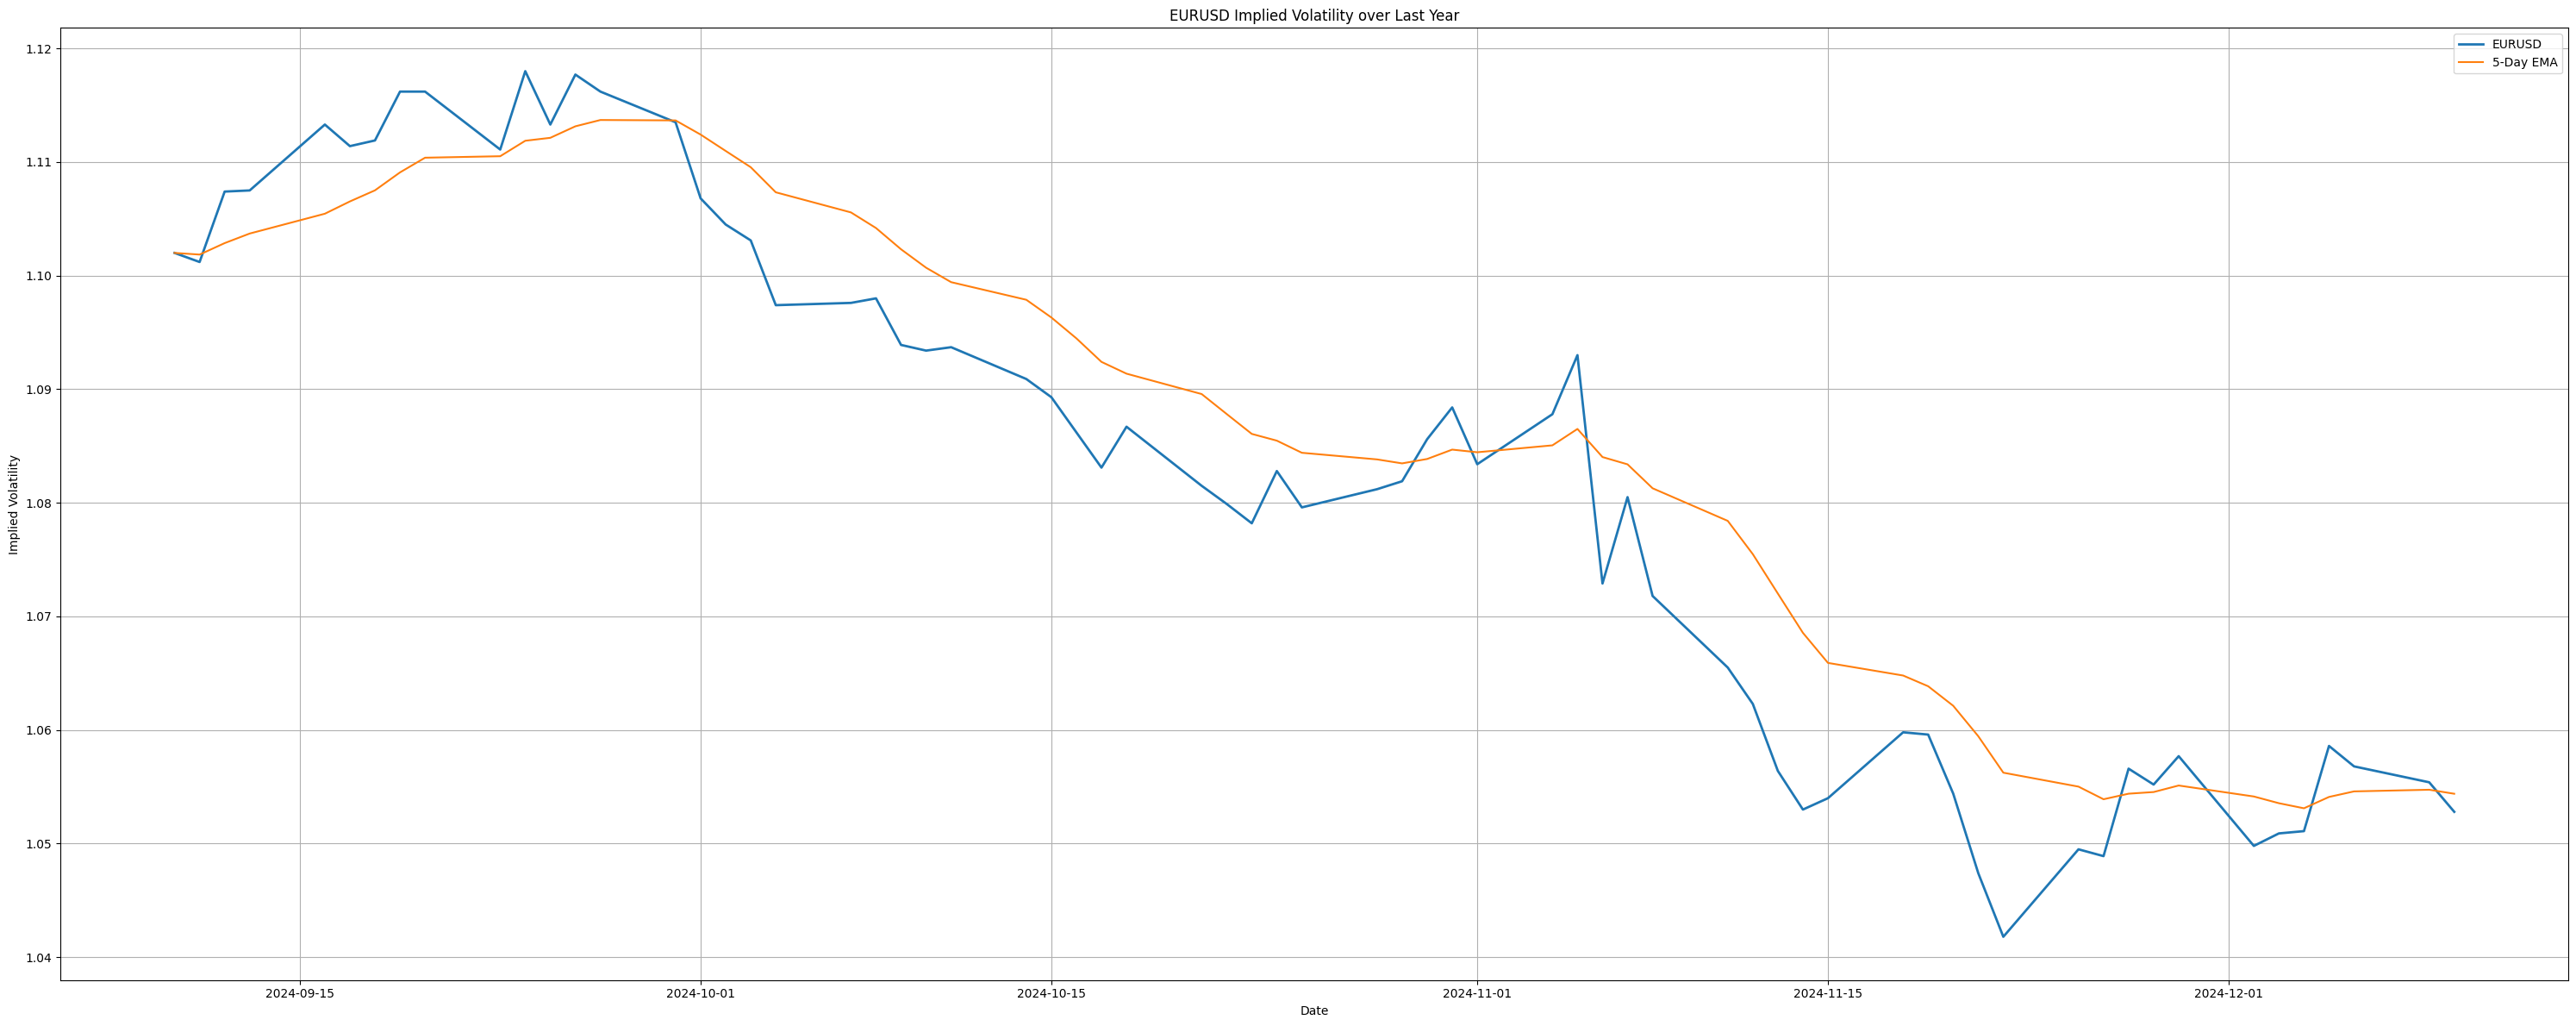

In [164]:
plt.figure(figsize=(30, 12))
plt.plot(data_spot.index, data_spot["EURUSD"], label="EURUSD", linewidth=2)
plt.plot(data_spot.index, data_spot['5D_EMA'], label="5-Day EMA")
# plt.plot(data_spot.index, data_spot['moving_Smooth'], label="Smoothed Path")
plt.title("EURUSD Implied Volatility over Last Year")
plt.xlabel("Date")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [160]:
std_dev = data_spot['ccy-moving_Smoo'].std()
mean_value = data_spot['ccy-moving_Smoo'].mean()

# Plot the distribution
plt.figure(figsize=(12, 6))
plt.hist(data_spot['ccy-moving_Smoo'], bins=30, alpha=0.7, label="Distribution", color='blue')

# Plot each standard deviation
for i in range(1, 4):  # Plot 1, 2, and 3 standard deviations
    plt.axvline(mean_value + i * std_dev, color='red', linestyle='--', label=f"+{i} STD")
    plt.axvline(mean_value - i * std_dev, color='green', linestyle='--', label=f"-{i} STD")

# Plot mean
plt.axvline(mean_value, color='black', linestyle='-', label="Mean")

# Customize the plot
plt.title("Distribution of 'ccy-moving_Smoo' with Standard Deviations")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

KeyError: 'ccy-moving_Smoo'

https://johoblogs.medium.com/mean-reversion-strategies-a0e54ddd5af8

In [20]:
import statsmodels.tsa.stattools as ts

In [25]:
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=365)).strftime("%Y-%m-%d")


data_spot = blp.bdh(
                tickers=f'{ticker} BGN Curncy',
                flds="PX_LAST",
                start_date=start_date,
                end_date=end_date
            )

data_spot.columns = [ticker]

adf = ts.adfuller(data_spot, 3)
print(adf)

# 1) Calculated test-statistic 
# 2) P-Value
# 3)
# 4) number of data points
# 5,6,7) Test-stat of 1, 5, 10% 

(np.float64(-1.2105841515817846), np.float64(0.669026185296386), 1, 260, {'1%': np.float64(-3.4557539868570775), '5%': np.float64(-2.8727214497041422), '10%': np.float64(-2.572728476331361)}, np.float64(-2121.274048091542))


In [27]:
data_spot

,EURUSD
2023-12-13,1.0874
2023-12-14,1.0993
2023-12-15,1.0895
2023-12-18,1.0924
2023-12-19,1.0981
...,...
2024-12-06,1.0568
2024-12-09,1.0554
2024-12-10,1.0527
2024-12-11,1.0496


In [ ]:
# --------------------------------------------------------------HAVE TO IMPORT BELOW APIS AGAIN---------------------------------------------------------------

In [64]:
import blpapi

import pdblp
from numpy import unique
import numpy as np
from xbbg import blp
from xbbg import blp, pipeline

from datetime import datetime, timedelta
import pandas as pd

from blp import blp

In [66]:
start_datetime = datetime.now() - timedelta(days=252)  # Example: 1 day before today
end_datetime = datetime.now()


bquery = blp.BlpQuery().start()

data = bquery.bdib(
    "EURUSD BGN Curncy",
    event_type="TRADE",
    interval=30,
    start_datetime=start_datetime, # Different date format
    end_datetime=end_datetime, # Different date format
)

adf = ts.adfuller(data['close'], 3)

adf

(np.float64(-0.5479730123254255),
 np.float64(0.8823100823842716),
 3,
 6891,
 {'1%': np.float64(-3.431299316152038),
  '5%': np.float64(-2.861959520427777),
  '10%': np.float64(-2.5669933068688353)},
 np.float64(-82354.46713814883))

In [68]:
import blpapi

import pdblp
from numpy import unique
import numpy as np
from xbbg import blp
from xbbg import blp, pipeline

from datetime import datetime, timedelta
import pandas as pd


from numpy import cumsum, log, polyfit, sqrt, std, subtract
from numpy.random import randn

In [25]:

days_past = 365
ticker = 'EURUSD'

end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=days_past)).strftime("%Y-%m-%d")


data_spot = blp.bdh(
                tickers=f'{ticker} BGN Curncy',
                flds="PX_LAST",
                start_date=start_date,
                end_date=end_date
            )

data_spot.columns = [ticker]

array_eurusd = data_spot.to_numpy()


def hurst(timeSeries):

    # Create the range of lag values
    lags = range(2, 50)

    # Calculate the array of the variances of the lagged differences
    tau = [sqrt(std(subtract(timeSeries[lag:], timeSeries[:-lag]))) for lag in lags]

    # Use a linear fit to estimate the Hurst Exponent
    poly = polyfit(log(lags), log(tau), 1)

    # Return the Hurst exponent from the polyfit output
    return poly[0]*2.0


brlusd_Hurst = hurst(array_eurusd)


In [26]:
brlusd_Hurst

np.float64(0.49059912124052196)

In [23]:
# Function to calculate Hurst exponent
def hurst(timeSeries):
    # Create the range of lag values
    lags = range(2, 100)

    # Calculate the array of the variances of the lagged differences
    tau = [sqrt(std(subtract(timeSeries[lag:], timeSeries[:-lag]))) for lag in lags]

    # Use a linear fit to estimate the Hurst Exponent
    poly = polyfit(log(lags), log(tau), 1)

    # Return the Hurst exponent from the polyfit output
    return poly[0] * 2.0



# Function to calculate Hurst exponents for multiple tickers
def calculate_hurst_for_tickers(tickers, days_past):
    end_date = datetime.now().strftime("%Y-%m-%d")
    start_date = (datetime.now() - timedelta(days=days_past)).strftime("%Y-%m-%d")

    hurst_exponents = {}

    for ticker in tickers:
        # Fetch historical data for the ticker
        data_spot = blp.bdh(
            tickers=f'{ticker} BGN Curncy',
            flds="PX_LAST",
            start_date=start_date,
            end_date=end_date
        )

        # Ensure the data is in the correct format
        if data_spot.empty:
            print(f"No data found for {ticker}. Skipping.")
            continue

        data_spot.columns = [ticker]

        # Convert the price column to a numpy array
        array_prices = data_spot[ticker].dropna().to_numpy()

        # Calculate the Hurst exponent
        hurst_exponent = hurst(array_prices)

        # Store the result in the dictionary
        hurst_exponents[ticker] = hurst_exponent


    hurst_df = pd.DataFrame(list(hurst_exponents.items()), columns=['Currency', 'Hurst Exponent'])

    hurst_df = hurst_df.sort_values(by='Hurst Exponent', ascending=True)

    return hurst_df

In [24]:
tickers = [
    'EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDNOK', 'USDSEK',
    'USDMXN', 'USDBRL', 'USDCNH'
]

days_past = 365
df_hurst_results = calculate_hurst_for_tickers(tickers, days_past)


df_hurst_results

,Currency,Hurst Exponent
10,USDBRL,0.201997
7,USDNOK,0.233093
4,NZDUSD,0.256962
3,AUDUSD,0.257807
5,USDCAD,0.285299
1,GBPUSD,0.336557
8,USDSEK,0.367536
0,EURUSD,0.372342
9,USDMXN,0.384318
11,USDCNH,0.422810


In [1]:
import blpapi

import pdblp
from numpy import unique
import numpy as np
from xbbg import blp
from xbbg import blp, pipeline

from datetime import datetime, timedelta
import pandas as pd


from numpy import cumsum, log, polyfit, sqrt, std, subtract
from numpy.random import randn

In [2]:
import blpapi

import pdblp
from numpy import unique
import numpy as np
from xbbg import blp
from xbbg import blp, pipeline

from datetime import datetime, timedelta
import pandas as pd


from numpy import cumsum, log, polyfit, sqrt, std, subtract
from numpy.random import randn

In [3]:


# Connect to Bloomberg
con = pdblp.BCon(debug=False, port=8194, timeout=5000)
con.start()

ccy = 'EURUSD'

# Fetch 1-year historical volatility
IV_data = con.ref(f"{ccy}V1W Curncy", ["PX_LAST"])  
df_IV = IV_data['value'].iloc[0]

df_IV

np.float64(8.56)

In [4]:
# Function to calculate Hurst exponent
def hurst(timeSeries):
    # Create the range of lag values
    lags = range(2, 100)

    # Calculate the array of the variances of the lagged differences
    tau = [sqrt(std(subtract(timeSeries[lag:], timeSeries[:-lag]))) for lag in lags]

    # Use a linear fit to estimate the Hurst Exponent
    poly = polyfit(log(lags), log(tau), 1)

    # Return the Hurst exponent from the polyfit output
    return poly[0] * 2.0





# Function to calculate Hurst exponents for multiple tickers
def calculate_hurst_for_tickers(tickers, days_past):
    end_date = datetime.now().strftime("%Y-%m-%d")
    start_date = (datetime.now() - timedelta(days=days_past)).strftime("%Y-%m-%d")

    hurst_exponents = {}
    iv_values = {}

    # Initialize Bloomberg connection
    con = pdblp.BCon(debug=False, port=8194, timeout=5000)
    con.start()

    for ticker in tickers:
        # Fetch historical data for the ticker
        data_spot = blp.bdh(
            tickers=f'{ticker} BGN Curncy',
            flds="PX_LAST",
            start_date=start_date,
            end_date=end_date
        )

        data_spot.columns = [ticker]

        # Convert the price column to a numpy array
        array_prices = data_spot[ticker].dropna().to_numpy()

        # Calculate the Hurst exponent
        hurst_exponent = hurst(array_prices)

        # Store the Hurst exponent
        hurst_exponents[ticker] = hurst_exponent

        # Fetch 1-year implied volatility for the ticker
        try:
            iv_data = con.ref(f"{ticker}V1Y Curncy", ["PX_LAST"])
            iv_value = iv_data["value"].iloc[0]
        except Exception as e:
            print(f"Error fetching IV for {ticker}: {e}")
            iv_value = None

        # Store the IV value
        iv_values[ticker] = iv_value

    # Create a DataFrame for Hurst exponents and IV values
    hurst_df = pd.DataFrame(list(hurst_exponents.items()), columns=['Currency', 'Hurst Exponent'])
    hurst_df['1Y Implied Volatility'] = hurst_df['Currency'].map(iv_values)

    # Sort the DataFrame by Hurst Exponent in ascending order
    hurst_df = hurst_df.sort_values(by='Hurst Exponent', ascending=True)

    return hurst_df








# Example usage:
tickers = [
    'EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDNOK', 'USDSEK',
    'USDMXN', 'USDBRL', 'USDCNH']


days_past = 365
df_hurst_results = calculate_hurst_for_tickers(tickers, days_past)


In [5]:
df_hurst_results

,Currency,Hurst Exponent,1Y Implied Volatility
10,USDBRL,0.200317,14.8000
7,USDNOK,0.248308,12.2225
4,NZDUSD,0.264519,10.2000
3,AUDUSD,0.265795,10.1650
5,USDCAD,0.302329,5.8600
1,GBPUSD,0.340688,7.9300
8,USDSEK,0.371893,11.4400
9,USDMXN,0.375048,13.8750
0,EURUSD,0.383177,7.6675
11,USDCNH,0.423952,7.1400


In [ ]:
# ---------------------------------TEST EUR MODEL PREDICT

euro_currencies = ['EURUSD', 'EURGBP', 'EURJPY', 'EURCHF', 'EURAUD', 'EURCAD', 'EURNZD', 'EURSEK']

end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=365)).strftime("%Y-%m-%d")

df_EUR = {}
for ccy in euro_currencies:
    ticker_IV = f"{ccy} BGN Curncy"
    data_IV = blp.bdh(
        tickers=ticker_IV,
        flds="PX_LAST",
        start_date=start_date,
        end_date=end_date
    )
    data_IV.columns = [ccy]
    df_EUR[ccy] = data_IV

# Combine all tenor data into a single DataFrame
df_all_EUR = pd.concat(df_EUR.values(), axis=1)



X = df_all_EUR[['EURGBP', 'EURJPY', 'EURCHF', 'EURAUD', 'EURCAD', 'EURNZD', 'EURSEK']]
y = df_all_EUR['EURUSD']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model (Random Forest)
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

In [62]:
X_actual = df_all_EUR[['EURGBP', 'EURJPY', 'EURCHF', 'EURAUD', 'EURCAD', 'EURNZD', 'EURSEK']]
y_actual = df_all_EUR['EURUSD']

# Predict EURUSD using the fitted model
predictions = model.predict(X_actual)

# Create a DataFrame to compare actual vs predicted
comparison_actual = pd.DataFrame({
    'Date': df_all_EUR.index,
    'Actual EURUSD': y_actual,
    'Predicted EURUSD': predictions
}).set_index('Date')
